In [3]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2Tokenizer

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

baseline_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
baseline_model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [6]:
text = "Artificial intelligence is transforming the world."
inputs = tokenizer(text, return_tensors="pt").to(device)

with torch.no_grad():
    baseline_logits = baseline_model(**inputs).logits

In [7]:
def kronecker_rank1(W, m1, m2, n1, n2):
    W = W.reshape(m1, m2, n1, n2)
    W = W.permute(0, 2, 1, 3).reshape(m1*n1, m2*n2)

    U, S, Vh = torch.linalg.svd(W, full_matrices=False)

    u = U[:, 0]
    v = Vh[0, :]
    s = S[0]

    A = (u * math.sqrt(s)).reshape(m1, n1)
    B = (v * math.sqrt(s)).reshape(m2, n2)

    return A.to(device), B.to(device)

In [8]:
class KronLinear(nn.Module):
    def __init__(self, A, B, bias, out_dim):
        super().__init__()
        self.A = nn.Parameter(A)
        self.B = nn.Parameter(B)
        self.bias = nn.Parameter(bias.clone().to(device))
        self.out_dim = out_dim
        self.m1, self.n1 = A.shape
        self.m2, self.n2 = B.shape

    def forward(self, x):
        batch, seq, _ = x.shape
        x = x.reshape(batch*seq, self.n1, self.n2)
        x = torch.matmul(x, self.B.t())
        x = torch.matmul(self.A, x)
        x = x.reshape(batch, seq, self.out_dim)
        return x + self.bias

In [9]:
def compress_single_layer(model, layer_idx):
    block = model.transformer.h[layer_idx]

    # c_fc
    W_fc = block.mlp.c_fc.weight.data.to(device)
    b_fc = block.mlp.c_fc.bias.data.to(device)

    A_fc, B_fc = kronecker_rank1(
        W_fc,
        m1=48, m2=64,
        n1=12, n2=64
    )

    block.mlp.c_fc = KronLinear(A_fc, B_fc, b_fc, out_dim=3072)

    # c_proj
    W_proj = block.mlp.c_proj.weight.data.to(device)
    b_proj = block.mlp.c_proj.bias.data.to(device)

    A_proj, B_proj = kronecker_rank1(
        W_proj,
        m1=12, m2=64,
        n1=48, n2=64
    )

    block.mlp.c_proj = KronLinear(A_proj, B_proj, b_proj, out_dim=768)

In [10]:
layer_results = []

for layer_idx in range(12):
    model_temp = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
    model_temp.eval()

    compress_single_layer(model_temp, layer_idx)

    with torch.no_grad():
        logits_temp = model_temp(**inputs).logits

    rel_diff = torch.norm(baseline_logits - logits_temp) / torch.norm(baseline_logits)
    layer_results.append(rel_diff.item())

    print(f"Layer {layer_idx} relative diff: {rel_diff.item():.4f}")

Layer 0 relative diff: 0.3034
Layer 1 relative diff: 0.0289
Layer 2 relative diff: 0.0363
Layer 3 relative diff: 0.0624
Layer 4 relative diff: 0.0440
Layer 5 relative diff: 0.0430
Layer 6 relative diff: 0.0411
Layer 7 relative diff: 0.0457
Layer 8 relative diff: 0.0670
Layer 9 relative diff: 0.0737
Layer 10 relative diff: 0.2208
Layer 11 relative diff: 0.1573


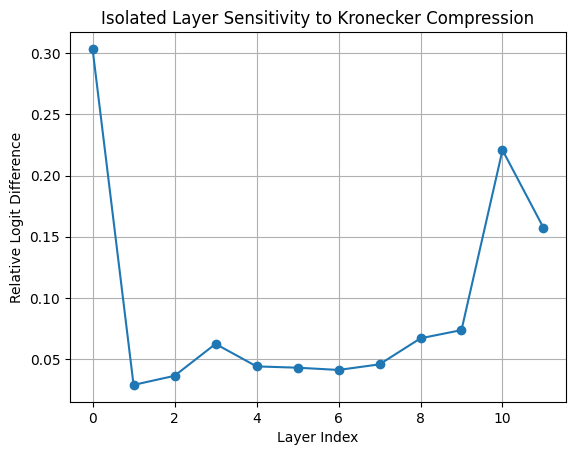

In [11]:
plt.figure()
plt.plot(range(12), layer_results, marker='o')

plt.xlabel("Layer Index")
plt.ylabel("Relative Logit Difference")
plt.title("Isolated Layer Sensitivity to Kronecker Compression")
plt.grid(True)
plt.show()

In [12]:
with torch.no_grad():
    baseline_logits = baseline_model(**inputs).logits

In [13]:
cumulative_results = []

for k in range(13):  # 0 to 12 layers
    model_temp = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
    model_temp.eval()

    # Compress first k layers
    for layer_idx in range(k):
        compress_single_layer(model_temp, layer_idx)

    with torch.no_grad():
        logits_temp = model_temp(**inputs).logits

    rel_diff = torch.norm(baseline_logits - logits_temp) / torch.norm(baseline_logits)

    cumulative_results.append(rel_diff.item())
    print(f"Cumulative compressed layers: {k}, Relative diff: {rel_diff.item():.4f}")

Cumulative compressed layers: 0, Relative diff: 0.0000
Cumulative compressed layers: 1, Relative diff: 0.3034
Cumulative compressed layers: 2, Relative diff: 0.3142
Cumulative compressed layers: 3, Relative diff: 0.3759
Cumulative compressed layers: 4, Relative diff: 0.6719
Cumulative compressed layers: 5, Relative diff: 0.7186
Cumulative compressed layers: 6, Relative diff: 0.5747
Cumulative compressed layers: 7, Relative diff: 0.7347
Cumulative compressed layers: 8, Relative diff: 0.6262
Cumulative compressed layers: 9, Relative diff: 0.6133
Cumulative compressed layers: 10, Relative diff: 0.5454
Cumulative compressed layers: 11, Relative diff: 0.5634
Cumulative compressed layers: 12, Relative diff: 0.8490


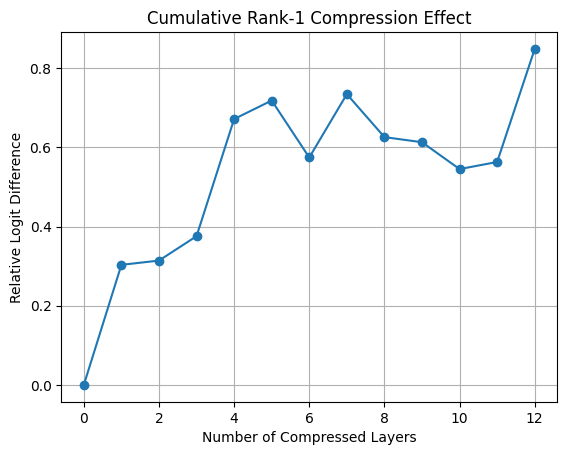

In [14]:
plt.figure()
plt.plot(range(13), cumulative_results, marker='o')

plt.xlabel("Number of Compressed Layers")
plt.ylabel("Relative Logit Difference")
plt.title("Cumulative Rank-1 Compression Effect")
plt.grid(True)
plt.show()

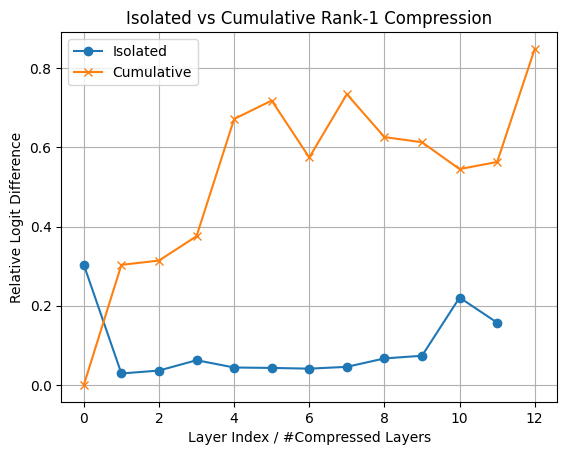

In [15]:
plt.figure()

plt.plot(range(12), layer_results, marker='o', label="Isolated")
plt.plot(range(13), cumulative_results, marker='x', label="Cumulative")

plt.xlabel("Layer Index / #Compressed Layers")
plt.ylabel("Relative Logit Difference")
plt.title("Isolated vs Cumulative Rank-1 Compression")
plt.legend()
plt.grid(True)
plt.show()

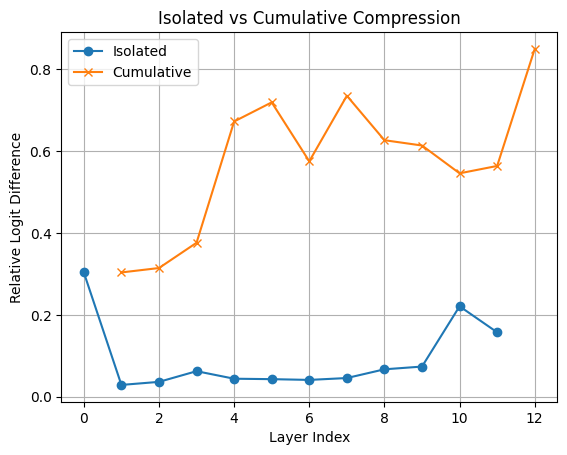

In [16]:
plt.figure()

plt.plot(range(12), layer_results, marker='o', label="Isolated")
plt.plot(range(1,13), cumulative_results[1:], marker='x', label="Cumulative")

plt.xlabel("Layer Index")
plt.ylabel("Relative Logit Difference")
plt.title("Isolated vs Cumulative Compression")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
import matplotlib.pyplot as plt
import numpy as np
isolated_array = np.array(layer_results).reshape(1, 12)

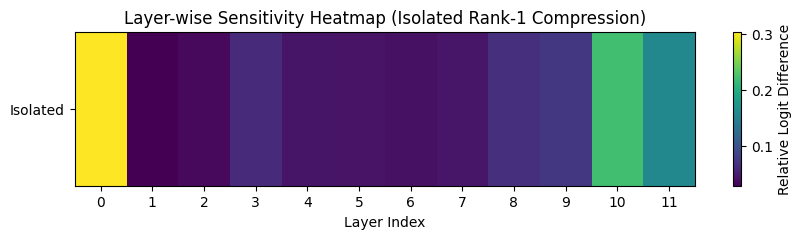

In [18]:
plt.figure(figsize=(10, 2))

plt.imshow(isolated_array, aspect='auto', cmap='viridis')
plt.colorbar(label="Relative Logit Difference")

plt.yticks([0], ["Isolated"])
plt.xticks(range(12), range(12))

plt.xlabel("Layer Index")
plt.title("Layer-wise Sensitivity Heatmap (Isolated Rank-1 Compression)")
plt.show()

In [19]:
cumulative_array = np.array(cumulative_results[1:]).reshape(1, 12)

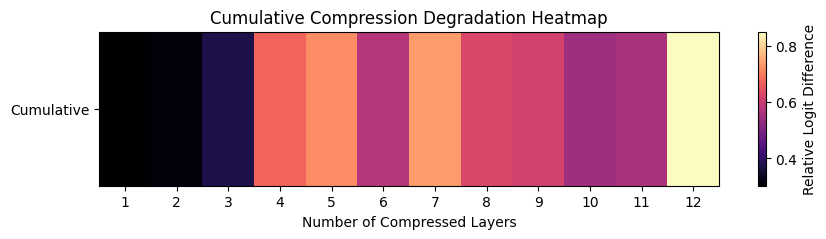

In [20]:
plt.figure(figsize=(10, 2))

plt.imshow(cumulative_array, aspect='auto', cmap='magma')
plt.colorbar(label="Relative Logit Difference")

plt.yticks([0], ["Cumulative"])
plt.xticks(range(12), range(1,13))

plt.xlabel("Number of Compressed Layers")
plt.title("Cumulative Compression Degradation Heatmap")
plt.show()

In [21]:
combined = np.vstack([isolated_array, cumulative_array])

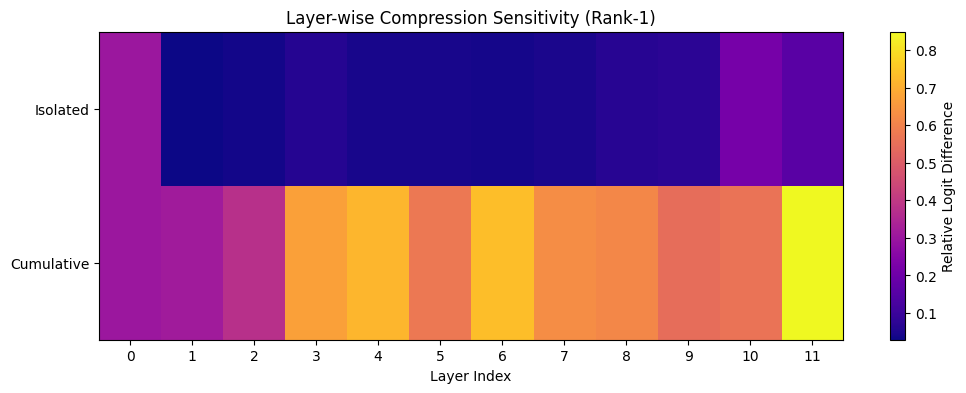

In [22]:

plt.figure(figsize=(12, 4))

plt.imshow(combined, aspect='auto', cmap='plasma')
plt.colorbar(label="Relative Logit Difference")

plt.yticks([0, 1], ["Isolated", "Cumulative"])
plt.xticks(range(12), range(12))

plt.xlabel("Layer Index")
plt.title("Layer-wise Compression Sensitivity (Rank-1)")
plt.show()

In [23]:
!pip install datasets

In [24]:
from datasets import load_dataset
from torch.utils.data import DataLoader

In [25]:
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

eval_texts = dataset["validation"]["text"]

In [26]:
def tokenize_function(examples):
    return tokenizer(
        examples,
        truncation=True,
        padding="max_length",
        max_length=128,
        return_tensors="pt"
    )

# Remove empty strings
eval_texts = [t for t in eval_texts if len(t.strip()) > 0]

tokenized = tokenizer(
    eval_texts,
    truncation=True,
    padding="max_length",
    max_length=128
)

In [27]:
class WikiDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.encodings["input_ids"][idx]),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx])
        }

eval_dataset = WikiDataset(tokenized)

eval_loader = DataLoader(eval_dataset, batch_size=8)

In [33]:
import math

def evaluate_perplexity(model, dataloader):
    model.eval()
    total_loss = 0
    total_tokens = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            labels = input_ids.clone()
            labels[attention_mask == 0] = -100

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss  # already averaged over tokens

            # Count real tokens (not padding)
            num_tokens = attention_mask.sum().item()

            total_loss += loss.item() * num_tokens
            total_tokens += num_tokens

    avg_loss = total_loss / total_tokens
    return math.exp(avg_loss)

In [34]:
cumulative_ppl = []

for k in range(13):
    model_temp = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

    for layer_idx in range(k):
        compress_single_layer(model_temp, layer_idx)

    ppl = evaluate_perplexity(model_temp, eval_loader)
    cumulative_ppl.append(ppl)

    print(f"Cumulative layers {k}: PPL = {ppl:.2f}")

Cumulative layers 0: PPL = 59.08
Cumulative layers 1: PPL = 4825.16
Cumulative layers 2: PPL = 3291.54
Cumulative layers 3: PPL = 5848.98
Cumulative layers 4: PPL = 8153.71
Cumulative layers 5: PPL = 8688.61
Cumulative layers 6: PPL = 10634.46
Cumulative layers 7: PPL = 9111.88
Cumulative layers 8: PPL = 16639.60
Cumulative layers 9: PPL = 13632.82
Cumulative layers 10: PPL = 12374.53
Cumulative layers 11: PPL = 11967.67
Cumulative layers 12: PPL = 50039.72


In [37]:
isolated_ppl = []

for layer_idx in range(12):
    model_temp = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

    compress_single_layer(model_temp, layer_idx)

    ppl = evaluate_perplexity(model_temp, eval_loader)
    isolated_ppl.append(ppl)

    print(f"Isolated layer {layer_idx}: PPL = {ppl:.2f}")

Isolated layer 0: PPL = 4825.16
Isolated layer 1: PPL = 61.56
Isolated layer 2: PPL = 62.77
Isolated layer 3: PPL = 63.76
Isolated layer 4: PPL = 66.66
Isolated layer 5: PPL = 65.00
Isolated layer 6: PPL = 64.60
Isolated layer 7: PPL = 62.94
Isolated layer 8: PPL = 65.63
Isolated layer 9: PPL = 65.38
Isolated layer 10: PPL = 64.50
Isolated layer 11: PPL = 67.49


In [35]:
import numpy as np

isolated_array = np.array(isolated_ppl).reshape(1, 12)
cumulative_array = np.array(cumulative_ppl[1:]).reshape(1, 12)

combined_ppl = np.vstack([isolated_array, cumulative_array])

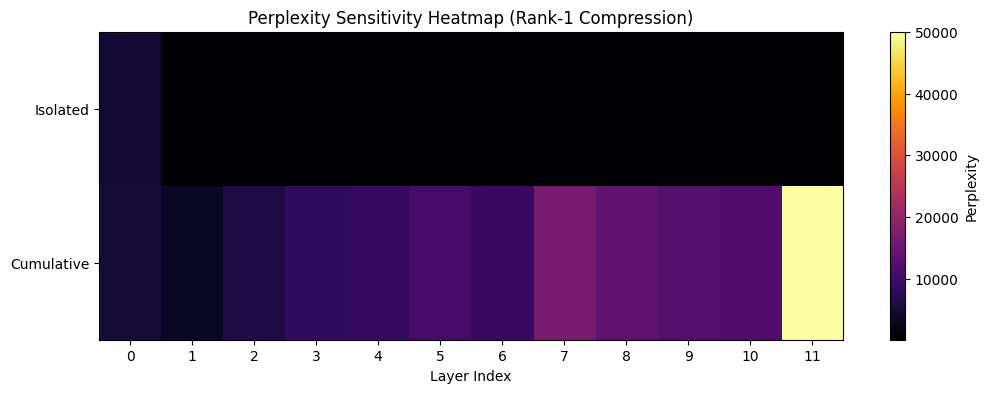

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.imshow(combined_ppl, aspect='auto', cmap='inferno')
plt.colorbar(label="Perplexity")

plt.yticks([0, 1], ["Isolated", "Cumulative"])
plt.xticks(range(12), range(12))

plt.xlabel("Layer Index")
plt.title("Perplexity Sensitivity Heatmap (Rank-1 Compression)")
plt.show()